In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

## Load data

In [2]:
df = pd.read_csv('../data/ab-test.csv')
print(df.shape)
df.head()

(44, 4)


,uid,diff,time,group
0,user_1,-103.333333,after,test
1,user_1,-6.000000,before,test
2,user_18,-10.000000,after,test
3,user_18,-3.500000,before,test
4,user_19,-82.333333,after,test


## Prepare data for boxplot

In [3]:
# Split by time
after = df[df['time'] == 'after']
before = df[df['time'] == 'before']

# Split each by group
after_test = after[after['group'] == 'test']['diff']
after_control = after[after['group'] == 'control']['diff']
before_test = before[before['group'] == 'test']['diff']
before_control = before[before['group'] == 'control']['diff']

print('After test:', len(after_test))
print('After control:', len(after_control))
print('Before test:', len(before_test))
print('Before control:', len(before_control))

After test: 7
After control: 15
Before test: 7
Before control: 15


## Plot boxplot

/var/folders/15/tbqvxp5j47jgxx_ykk5nrrtc0000gn/T/ipykernel_13526/2329074077.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
/var/folders/15/tbqvxp5j47jgxx_ykk5nrrtc0000gn/T/ipykernel_13526/2329074077.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


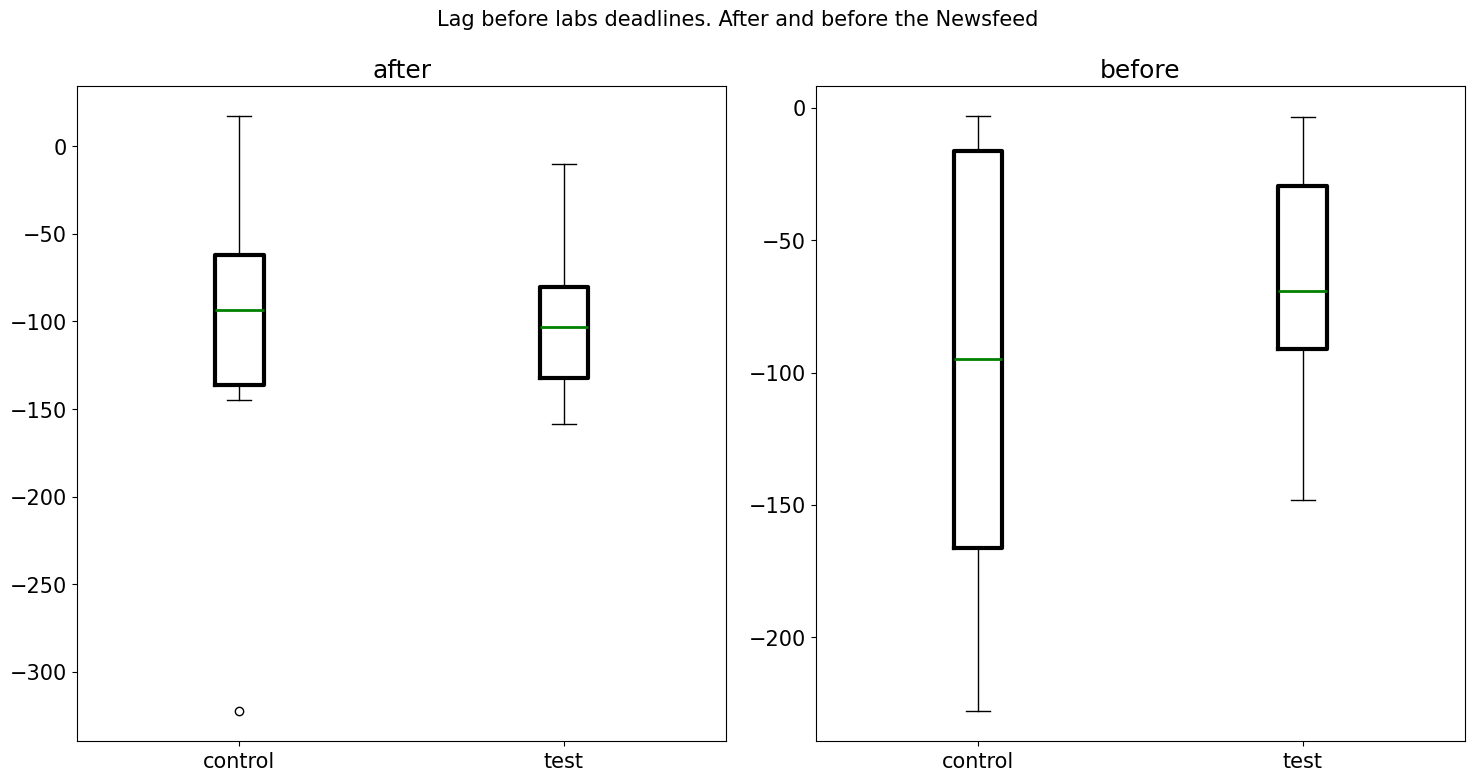

In [4]:
plt.rcParams['font.size'] = 15
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# After plot
axes[0].boxplot(
    [after_control, after_test],
    labels=['control', 'test'],
    boxprops=dict(linewidth=3),
    medianprops=dict(linewidth=2, color='green')
)
axes[0].set_title('after')

# Before plot
axes[1].boxplot(
    [before_control, before_test],
    labels=['control', 'test'],
    boxprops=dict(linewidth=3),
    medianprops=dict(linewidth=2, color='green')
)
axes[1].set_title('before')

fig.suptitle('Lag before labs deadlines. After and before the Newsfeed', fontsize=15)
plt.tight_layout()
plt.show()

## Answer question

In [5]:
q1 = before_control.quantile(0.25)
q3 = before_control.quantile(0.75)
iqr = q3 - q1
print(f'IQR of control group before the newsfeed: {iqr:.1f}')
print(f'Rounded to nearest 10: {round(iqr / 10) * 10}')

IQR of control group before the newsfeed: 150.0
Rounded to nearest 10: 150


What was the IQR of the control group before the newsfeed? The answer rounded to the nearest 10: 150.